In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv(r"C:\Projects\global_supply_chain_mlops\data\data.csv")
df

,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
0,ORD-00BCB25B,2024-04-05,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,18,0,On Time,NaN,0.81,8.9,1.83,1611.81,1781,Standard Shipping
1,ORD-EBDBACB7,2024-09-08,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,2,0,On Time,NaN,0.70,5.9,2.44,76127.70,8142,Standard Shipping
2,ORD-4052DA06,2025-01-28,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,4,0,On Time,NaN,0.46,8.1,3.86,13699.18,1706,Standard Shipping
3,ORD-03F41ABB,2025-02-04,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,35,0,On Time,NaN,0.88,9.3,1.58,5448.24,5796,Standard Shipping
4,ORD-347A88A6,2025-05-20,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.55,2.9,3.12,1215.98,1569,Standard Shipping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ORD-525E3FA5,2024-10-14,"Tokyo, JP","Singapore, SG",Intra-Asia,Sea,Consumer Electronics,7,8,8,0,On Time,NaN,0.58,8.1,3.38,7346.21,9299,Standard Shipping
9996,ORD-5E9DBD46,2024-09-10,"Tokyo, JP","Singapore, SG",Intra-Asia,Sea,Textiles,7,10,7,0,On Time,NaN,0.37,5.5,2.34,4112.06,6003,Standard Shipping
9997,ORD-E6949429,2024-07-13,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.84,1.0,4.56,7346.20,7985,Standard Shipping
9998,ORD-29B9A2DA,2024-07-21,"Mumbai, IN","Felixstowe, UK",Suez,Sea,Semiconductors,24,27,25,0,On Time,NaN,0.53,4.7,1.05,5810.94,7596,Standard Shipping


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  10000 non-null  str    
 1   Order_Date                10000 non-null  str    
 2   Origin_City               10000 non-null  str    
 3   Destination_City          10000 non-null  str    
 4   Route_Type                10000 non-null  str    
 5   Transportation_Mode       10000 non-null  str    
 6   Product_Category          10000 non-null  str    
 7   Base_Lead_Time_Days       10000 non-null  int64  
 8   Scheduled_Lead_Time_Days  10000 non-null  int64  
 9   Actual_Lead_Time_Days     10000 non-null  int64  
 10  Delay_Days                10000 non-null  int64  
 11  Delivery_Status           10000 non-null  str    
 12  Disruption_Event          1267 non-null   str    
 13  Geopolitical_Risk_Index   10000 non-null  float64
 14  Weather_Severity_I

In [61]:
df.describe(include='all')

,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
count,10000,10000,10000,10000,10000,10000,10000,10000.000000,10000.00000,10000.000000,10000.000000,10000,1267,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000
unique,10000,731,6,6,5,2,7,NaN,NaN,NaN,NaN,2,3,NaN,NaN,NaN,NaN,NaN,3
top,ORD-00BCB25B,2024-02-01,"Mumbai, IN","Felixstowe, UK",Suez,Sea,Consumer Electronics,NaN,NaN,NaN,NaN,On Time,Port Congestion,NaN,NaN,NaN,NaN,NaN,Standard Shipping
freq,1,29,1710,1710,3412,8271,1458,NaN,NaN,NaN,NaN,8710,573,NaN,NaN,NaN,NaN,NaN,9283
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.509900,19.50320,18.704300,0.947500,NaN,NaN,0.496770,4.976460,3.516010,11437.916337,5033.732500,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.902843,10.93356,11.662815,3.117293,NaN,NaN,0.230611,2.879658,1.209597,21086.689659,2830.996788,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,3.00000,1.000000,0.000000,NaN,NaN,0.100000,0.000000,-1.150000,59.940000,101.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,9.00000,7.000000,0.000000,NaN,NaN,0.300000,2.500000,2.700000,2308.387500,2590.500000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,20.00000,18.000000,0.000000,NaN,NaN,0.500000,4.900000,3.500000,4520.170000,5044.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.000000,29.00000,28.000000,0.000000,NaN,NaN,0.690000,7.500000,4.350000,7055.107500,7493.000000,NaN


In [62]:
df.isnull().sum()

Order_ID                       0
Order_Date                     0
Origin_City                    0
Destination_City               0
Route_Type                     0
Transportation_Mode            0
Product_Category               0
Base_Lead_Time_Days            0
Scheduled_Lead_Time_Days       0
Actual_Lead_Time_Days          0
Delay_Days                     0
Delivery_Status                0
Disruption_Event            8733
Geopolitical_Risk_Index        0
Weather_Severity_Index         0
Inflation_Rate_Pct             0
Shipping_Cost_USD              0
Order_Weight_Kg                0
Mitigation_Action_Taken        0
dtype: int64

In [63]:
df.nunique()

Order_ID                    10000
Order_Date                    731
Origin_City                     6
Destination_City                6
Route_Type                      5
Transportation_Mode             2
Product_Category                7
Base_Lead_Time_Days             9
Scheduled_Lead_Time_Days       23
Actual_Lead_Time_Days          48
Delay_Days                     21
Delivery_Status                 2
Disruption_Event                3
Geopolitical_Risk_Index        81
Weather_Severity_Index        101
Inflation_Rate_Pct            679
Shipping_Cost_USD            9898
Order_Weight_Kg              6303
Mitigation_Action_Taken         3
dtype: int64

In [64]:
df['Route_Type'].unique()

<ArrowStringArray>
['Pacific', 'Intra-Asia', 'Suez', 'Commodity', 'Atlantic']
Length: 5, dtype: str

In [65]:
df['Destination_City'].unique()

<ArrowStringArray>
['Los Angeles, US',   'Singapore, SG',   'Rotterdam, NL',    'Shanghai, CN',
    'New York, US',  'Felixstowe, UK']
Length: 6, dtype: str

In [66]:
df['Origin_City'].unique()

<ArrowStringArray>
['Shanghai, CN',    'Tokyo, JP', 'Shenzhen, CN',   'Santos, BR',
  'Hamburg, DE',   'Mumbai, IN']
Length: 6, dtype: str

In [67]:
df['Delivery_Status'].unique()

<ArrowStringArray>
['On Time', 'Late']
Length: 2, dtype: str

In [68]:
df['Transportation_Mode'].unique()

<ArrowStringArray>
['Sea', 'Air']
Length: 2, dtype: str

In [69]:
df['Product_Category'].unique()

<ArrowStringArray>
[            'Textiles',      'Pharmaceuticals',       'Semiconductors',
 'Consumer Electronics',        'Raw Materials',           'Auto Parts',
     'Perishable Foods']
Length: 7, dtype: str

In [70]:
df['Delivery_Status'].unique()

<ArrowStringArray>
['On Time', 'Late']
Length: 2, dtype: str

In [71]:
df['Disruption_Event'].unique()

<ArrowStringArray>
[                                      nan,
                         'Port Congestion',
 'Geopolitical Conflict (Route Diversion)',
          'Severe Weather (Typhoon/Storm)']
Length: 4, dtype: str

In [72]:
df['Mitigation_Action_Taken'].unique()

<ArrowStringArray>
['Standard Shipping', 'Expedited Air Freight', 'Re-routing']
Length: 3, dtype: str

In [73]:
df['Disruption_Event'] = df['Disruption_Event'].fillna('No Disruption')

In [74]:
encoded_df = pd.get_dummies(df,columns=['Route_Type','Destination_City','Origin_City','Delivery_Status','Transportation_Mode','Product_Category','Disruption_Event'])

In [75]:
encoded_df

,Order_ID,Order_Date,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,...,Product_Category_Consumer Electronics,Product_Category_Perishable Foods,Product_Category_Pharmaceuticals,Product_Category_Raw Materials,Product_Category_Semiconductors,Product_Category_Textiles,Disruption_Event_Geopolitical Conflict (Route Diversion),Disruption_Event_No Disruption,Disruption_Event_Port Congestion,Disruption_Event_Severe Weather (Typhoon/Storm)
0,ORD-00BCB25B,2024-04-05,18,21,18,0,0.81,8.9,1.83,1611.81,...,False,False,False,False,False,True,False,True,False,False
1,ORD-EBDBACB7,2024-09-08,2,5,2,0,0.70,5.9,2.44,76127.70,...,False,False,True,False,False,False,False,True,False,False
2,ORD-4052DA06,2025-01-28,3,4,4,0,0.46,8.1,3.86,13699.18,...,False,False,False,False,True,False,False,True,False,False
3,ORD-03F41ABB,2025-02-04,35,36,35,0,0.88,9.3,1.58,5448.24,...,True,False,False,False,False,False,False,True,False,False
4,ORD-347A88A6,2025-05-20,12,13,12,0,0.55,2.9,3.12,1215.98,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ORD-525E3FA5,2024-10-14,7,8,8,0,0.58,8.1,3.38,7346.21,...,True,False,False,False,False,False,False,True,False,False
9996,ORD-5E9DBD46,2024-09-10,7,10,7,0,0.37,5.5,2.34,4112.06,...,False,False,False,False,False,True,False,True,False,False
9997,ORD-E6949429,2024-07-13,12,13,12,0,0.84,1.0,4.56,7346.20,...,False,False,False,True,False,False,False,True,False,False
9998,ORD-29B9A2DA,2024-07-21,24,27,25,0,0.53,4.7,1.05,5810.94,...,False,False,False,False,True,False,False,True,False,False


In [76]:
encoded_df = encoded_df.drop(['Order_ID','Order_Date'], axis=1)

In [77]:
encoded_df

,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken,...,Product_Category_Consumer Electronics,Product_Category_Perishable Foods,Product_Category_Pharmaceuticals,Product_Category_Raw Materials,Product_Category_Semiconductors,Product_Category_Textiles,Disruption_Event_Geopolitical Conflict (Route Diversion),Disruption_Event_No Disruption,Disruption_Event_Port Congestion,Disruption_Event_Severe Weather (Typhoon/Storm)
0,18,21,18,0,0.81,8.9,1.83,1611.81,1781,Standard Shipping,...,False,False,False,False,False,True,False,True,False,False
1,2,5,2,0,0.70,5.9,2.44,76127.70,8142,Standard Shipping,...,False,False,True,False,False,False,False,True,False,False
2,3,4,4,0,0.46,8.1,3.86,13699.18,1706,Standard Shipping,...,False,False,False,False,True,False,False,True,False,False
3,35,36,35,0,0.88,9.3,1.58,5448.24,5796,Standard Shipping,...,True,False,False,False,False,False,False,True,False,False
4,12,13,12,0,0.55,2.9,3.12,1215.98,1569,Standard Shipping,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,7,8,8,0,0.58,8.1,3.38,7346.21,9299,Standard Shipping,...,True,False,False,False,False,False,False,True,False,False
9996,7,10,7,0,0.37,5.5,2.34,4112.06,6003,Standard Shipping,...,False,False,False,False,False,True,False,True,False,False
9997,12,13,12,0,0.84,1.0,4.56,7346.20,7985,Standard Shipping,...,False,False,False,True,False,False,False,True,False,False
9998,24,27,25,0,0.53,4.7,1.05,5810.94,7596,Standard Shipping,...,False,False,False,False,True,False,False,True,False,False


<Axes: xlabel='Disruption_Event'>

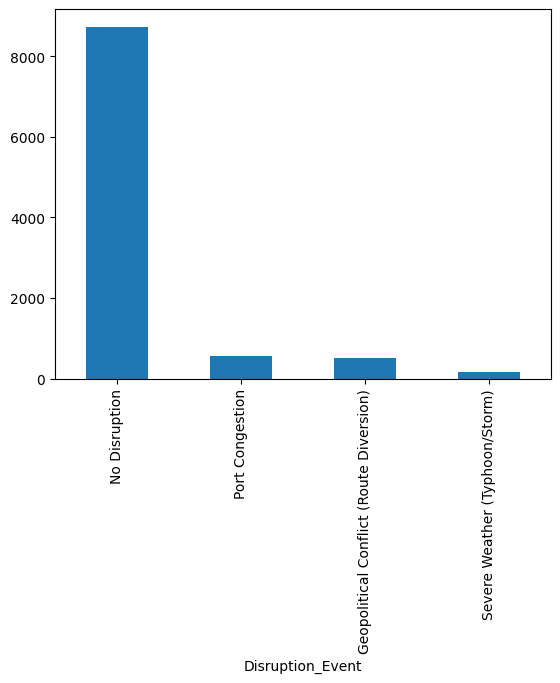

In [78]:
df['Disruption_Event'].value_counts().plot(kind='bar')

In [95]:
encoded_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 42 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Base_Lead_Time_Days                                       10000 non-null  int64  
 1   Scheduled_Lead_Time_Days                                  10000 non-null  int64  
 2   Actual_Lead_Time_Days                                     10000 non-null  int64  
 3   Delay_Days                                                10000 non-null  int64  
 4   Geopolitical_Risk_Index                                   10000 non-null  float64
 5   Weather_Severity_Index                                    10000 non-null  float64
 6   Inflation_Rate_Pct                                        10000 non-null  float64
 7   Shipping_Cost_USD                                         10000 non-null  float64
 8   Order_Weight_Kg             

In [96]:
X_train = encoded_df.drop('Mitigation_Action_Taken', axis=1)

In [98]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Base_Lead_Time_Days                                       10000 non-null  int64  
 1   Scheduled_Lead_Time_Days                                  10000 non-null  int64  
 2   Actual_Lead_Time_Days                                     10000 non-null  int64  
 3   Delay_Days                                                10000 non-null  int64  
 4   Geopolitical_Risk_Index                                   10000 non-null  float64
 5   Weather_Severity_Index                                    10000 non-null  float64
 6   Inflation_Rate_Pct                                        10000 non-null  float64
 7   Shipping_Cost_USD                                         10000 non-null  float64
 8   Order_Weight_Kg             

In [80]:
X_train = encoded_df.drop('Mitigation_Action_Taken', axis=1).values
y_train = encoded_df['Mitigation_Action_Taken'].values

In [94]:
X_train

array([[18, 21, 18, ..., True, False, False],
       [2, 5, 2, ..., True, False, False],
       [3, 4, 4, ..., True, False, False],
       ...,
       [12, 13, 12, ..., True, False, False],
       [24, 27, 25, ..., True, False, False],
       [12, 14, 12, ..., True, False, False]], dtype=object)

In [82]:
y_train

<ArrowStringArray>
[    'Standard Shipping',     'Standard Shipping',     'Standard Shipping',
     'Standard Shipping',     'Standard Shipping',     'Standard Shipping',
     'Standard Shipping',     'Standard Shipping', 'Expedited Air Freight',
     'Standard Shipping',
 ...
     'Standard Shipping',     'Standard Shipping',     'Standard Shipping',
     'Standard Shipping',     'Standard Shipping',     'Standard Shipping',
     'Standard Shipping',     'Standard Shipping',     'Standard Shipping',
     'Standard Shipping']
Length: 10000, dtype: str

In [89]:
import os

BASE_DIR = os.path.dirname(os.getcwd())

In [90]:
model_path = os.path.join(BASE_DIR, "model.pkl")
test_data_path = os.path.join(BASE_DIR, "data/processed/test_processed.csv")

In [91]:
print("BASE_DIR:", BASE_DIR)

print("PATH:", test_data_path)

BASE_DIR: c:\Projects\global_supply_chain_mlops
PATH: c:\Projects\global_supply_chain_mlops\data/processed/test_processed.csv


In [92]:
import numpy as np
import pandas as pd
import os
import pickle
import json 

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score



test_data = pd.read_csv(test_data_path)
X_test = test_data.drop('Mitigation_Action_Taken', axis=1).values
y_test = test_data['Mitigation_Action_Taken'].values
model = pickle.load(open(model_path, 'rb'))
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

In [93]:
y_pred

array(['Standard Shipping', 'Standard Shipping', 'Standard Shipping', ...,
       'Re-routing', 'Standard Shipping', 'Standard Shipping'],
      dtype=object)